# 1. Initial Setup: Data Loading, Preprocessing & Feature Engineering

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    ConfusionMatrixDisplay
)
import xgboost as xgb
from mlxtend.frequent_patterns import apriori, association_rules

In [42]:
# Data Loading
df = pd.read_csv('/content/ML_Dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Temporal Split
train_list, test_list = [], []
for pid, grp in df.groupby('id'):
    grp = grp.sort_values('date')
    split = int(len(grp) * 0.8)
    train_list.append(grp.iloc[:split])
    test_list.append(grp.iloc[split:])

train = pd.concat(train_list)
test = pd.concat(test_list)

# Target Binning
q33 = train['mood_target'].quantile(0.33)
q66 = train['mood_target'].quantile(0.66)

def bin_classes(s):
    return pd.cut(s, bins=[0, q33, q66, 10], labels=[0,1,2]).astype(int)

# Feature Selection
ALL_FEATURES = [c for c in df.columns if c not in ['id','date','mood_target']]
FEATURES = ALL_FEATURES # Alias for consistency

# Classification Data
y_train_cls = bin_classes(train['mood_target'])
y_test_cls = bin_classes(test['mood_target'])

# Regression Data
X_train = train[ALL_FEATURES]
X_test = test[ALL_FEATURES]
y_train_reg = train['mood_target']
y_test_reg = test['mood_target']

### Training Set Class Distribution

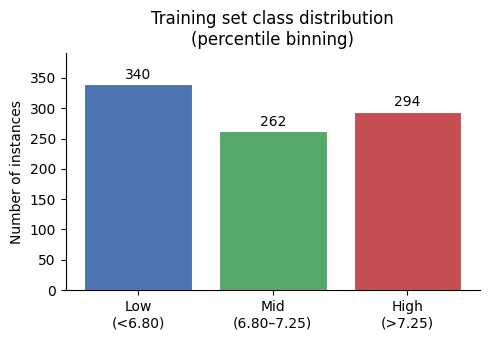

In [43]:
# Class Distribution Plot
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = pd.Series(y_train_cls).value_counts().sort_index()
bars = ax.bar(['Low\n(<6.80)', 'Mid\n(6.80–7.25)', 'High\n(>7.25)'] ,
              counts.values, color=['#4C72B0', '#55A868', '#C44E52'],
              edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            str(v), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of instances')
ax.set_title('Training set class distribution\n(percentile binning)')
ax.set_ylim(0, max(counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# 2. Classification Models

### XGBoost Classifier

In [44]:
# XGBoost CLASSIFIER
xgb_cls = xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', use_label_encoder=False, random_state=42)

xgb_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

xgb_cv = GridSearchCV(
    xgb_cls,
    xgb_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

xgb_cv.fit(X_train, y_train_cls) # Use X_train here as it includes all features
xgb_best = xgb_cv.best_estimator_
xgb_pred = xgb_best.predict(X_test) # Use X_test here as it includes all features

print("\n=== XGBoost CLASSIFIER ===")
print("Best params:", xgb_cv.best_params_)
print("Weighted F1:", f1_score(y_test_cls, xgb_pred, average='weighted'))
print("Macro F1:", f1_score(y_test_cls, xgb_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test_cls, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls, xgb_pred))


=== XGBoost CLASSIFIER ===
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Weighted F1: 0.5368390987889503
Macro F1: 0.527467204894637

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.70      0.62        90
           1       0.41      0.30      0.34        71
           2       0.63      0.61      0.62        76

    accuracy                           0.55       237
   macro avg       0.53      0.53      0.53       237
weighted avg       0.54      0.55      0.54       237

Confusion Matrix:
 [[63 16 11]
 [34 21 16]
 [16 14 46]]


#### XGBoost Classifier Performance Visualizations

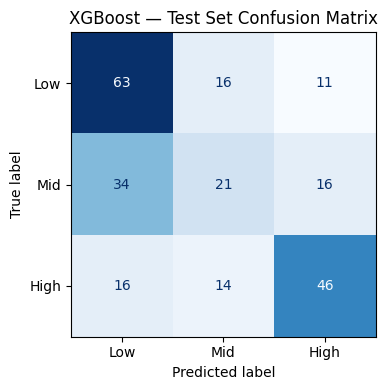

In [45]:
# XGBoost Confusion Matrix
cm = confusion_matrix(y_test_cls, xgb_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low', 'Mid', 'High'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

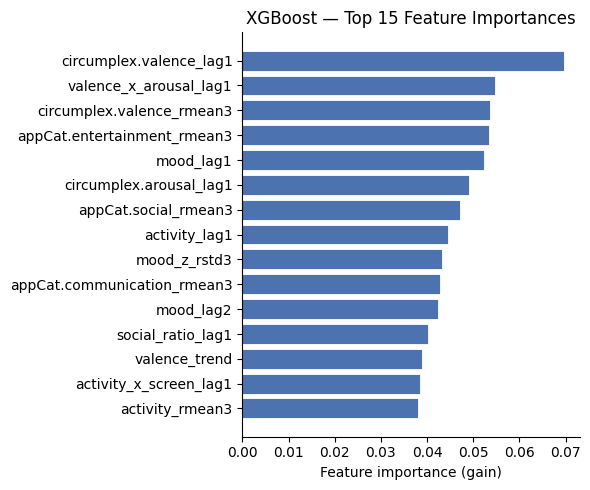

In [46]:
# XGBoost Top 15 Feature Importances
importances = pd.Series(xgb_cv.best_estimator_.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.barh(importances.index, importances.values,
               color='#4C72B0', edgecolor='white', linewidth=0.6)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost — Top 15 Feature Importances')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Random Forest Classifier (Top 10 Features)

In [47]:
# Select top 10 features based on XGBoost importance
importances = pd.Series(xgb_cv.best_estimator_.feature_importances_, index=ALL_FEATURES)
importances = importances.sort_values(ascending=False).head(10)
top_10_features = importances.index.tolist()

print("Top 10 features defined:", top_10_features)

X_train_rf = train[top_10_features]
X_test_rf = test[top_10_features]

# Initialize and train RandomForestClassifier
rf_cls = RandomForestClassifier(random_state=42)
rf_cls.fit(X_train_rf, y_train_cls)
rf_pred = rf_cls.predict(X_test_rf)

print("\n=== RANDOM FOREST CLASSIFIER (TOP 10 FEATURES) ===")
print("Weighted F1:", f1_score(y_test_cls, rf_pred, average='weighted'))
print("Macro F1:", f1_score(y_test_cls, rf_pred, average='macro'))
print("Accuracy:", (y_test_cls == rf_pred).mean())
print("\nClassification Report:\n", classification_report(y_test_cls, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls, rf_pred))

Top 10 features defined: ['circumplex.valence_lag1', 'valence_x_arousal_lag1', 'circumplex.valence_rmean3', 'appCat.entertainment_rmean3', 'mood_lag1', 'circumplex.arousal_lag1', 'appCat.social_rmean3', 'activity_lag1', 'mood_z_rstd3', 'appCat.communication_rmean3']

=== RANDOM FOREST CLASSIFIER (TOP 10 FEATURES) ===
Weighted F1: 0.4939160294463724
Macro F1: 0.4857187745483111
Accuracy: 0.4978902953586498

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.61      0.58        90
           1       0.38      0.34      0.36        71
           2       0.53      0.51      0.52        76

    accuracy                           0.50       237
   macro avg       0.49      0.49      0.49       237
weighted avg       0.49      0.50      0.49       237

Confusion Matrix:
 [[55 22 13]
 [25 24 22]
 [20 17 39]]


# 3. Regression Models

### Naive Baseline (Train Mean)

In [48]:
# Calculate the mean of the training target variable
train_mean = y_train_reg.mean()

# Create a naive prediction array
naive_pred = np.full_like(y_test_reg, train_mean)

# Calculate metrics for the naive baseline
naive_mse = mean_squared_error(y_test_reg, naive_pred)
naive_mae = mean_absolute_error(y_test_reg, naive_pred)
naive_rmse = np.sqrt(naive_mse)

print("\n=== NAIVE BASELINE (TRAIN MEAN) ===")
print(f"MSE: {naive_mse:.3f}")
print(f"MAE: {naive_mae:.3f}")
print(f"RMSE: {naive_rmse:.3f}")


=== NAIVE BASELINE (TRAIN MEAN) ===
MSE: 0.525
MAE: 0.546
RMSE: 0.725


### Ridge Regression

In [49]:
# Ridge Regression (initial, untuned)
ridge = Ridge()
ridge.fit(X_train, y_train_reg)
ridge_pred = ridge.predict(X_test)

ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
ridge_mae = mean_absolute_error(y_test_reg, ridge_pred)

print("\n=== RIDGE REGRESSION (INITIAL) ===")
print("MSE:", ridge_mse)
print("MAE:", ridge_mae)

# Error Analysis (initial Ridge)
errors = pd.DataFrame({
    'true': y_test_reg,
    'pred': ridge_pred
})
errors['abs_error'] = np.abs(errors['true'] - errors['pred'])
errors['sq_error'] = (errors['true'] - errors['pred'])**2

print("\n=== ERROR ANALYSIS (RIDGE REGRESSOR - INITIAL) ===")
print(errors.sort_values(by='abs_error', ascending=False).head())


=== RIDGE REGRESSION (INITIAL) ===
MSE: 0.40513300885730275
MAE: 0.48781241342858433

=== ERROR ANALYSIS (RIDGE REGRESSOR - INITIAL) ===
     true      pred  abs_error  sq_error
254   5.0  6.964018   1.964018  3.857365
380   4.8  6.715434   1.915434  3.668886
735   9.0  7.157816   1.842184  3.393641
256   5.0  6.626952   1.626952  2.646972
423   8.8  7.191181   1.608819  2.588300


#### Ridge Regression Evaluation Visualizations

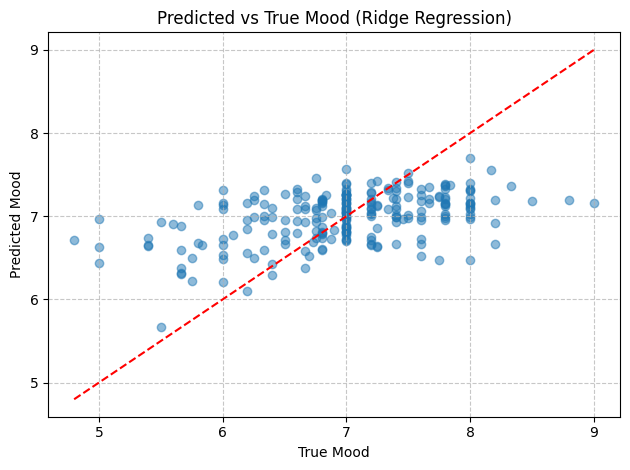

In [50]:
# Predicted vs True Mood (Ridge Regression)
plt.figure()
plt.scatter(y_test_reg, ridge_pred, alpha=0.5)
plt.xlabel("True Mood")
plt.ylabel("Predicted Mood")
plt.title("Predicted vs True Mood (Ridge Regression)")
plt.plot([min(y_test_reg), max(y_test_reg)],
         [min(y_test_reg), max(y_test_reg)], color='red', linestyle='--') # Add ideal line
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

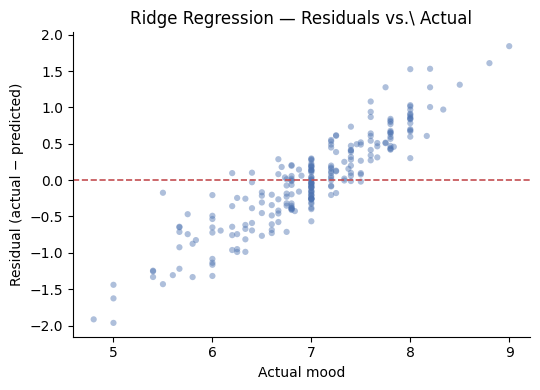

In [51]:
# Ridge Residuals vs. Actual
residuals = y_test_reg - ridge_pred
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(y_test_reg, residuals, alpha=0.45, s=20,
           color='#4C72B0', edgecolors='none')
ax.axhline(0, color='#C44E52', linewidth=1.2, linestyle='--')
ax.set_xlabel('Actual mood')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Ridge Regression — Residuals vs.\\ Actual')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Ridge Regression Hyperparameter Optimization

In [52]:
# Define the pipeline for Ridge Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define the parameter grid for alpha
param_grid = {'ridge__alpha': [0.1, 1.0, 10.0]}

# Perform GridSearchCV
ridge_grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit on the training data
ridge_grid_search.fit(X_train, y_train_reg)

# Get the best estimator and its parameters
best_ridge_model = ridge_grid_search.best_estimator_
best_alpha = ridge_grid_search.best_params_['ridge__alpha']

# Make predictions with the best model
ridge_tuned_pred = best_ridge_model.predict(X_test)

# Calculate metrics for the tuned Ridge model
ridge_tuned_mse = mean_squared_error(y_test_reg, ridge_tuned_pred)
ridge_tuned_mae = mean_absolute_error(y_test_reg, ridge_tuned_pred)
ridge_tuned_rmse = np.sqrt(ridge_tuned_mse)

print("\n=== RIDGE REGRESSION (TUNED) ===")
print(f"Best alpha: {best_alpha}")
print(f"MSE: {ridge_tuned_mse:.3f}")
print(f"MAE: {ridge_tuned_mae:.3f}")
print(f"RMSE: {ridge_tuned_rmse:.3f}")


=== RIDGE REGRESSION (TUNED) ===
Best alpha: 10.0
MSE: 0.401
MAE: 0.485
RMSE: 0.634


#### Ridge Regression MSE by Mood Class Analysis

In [53]:
residuals_ridge_orig = y_test_reg - ridge_pred

# Create a DataFrame for error analysis, including squared errors
errors_by_class = pd.DataFrame({
    'true_mood': y_test_reg,
    'squared_error': residuals_ridge_orig**2
})

mood_class_labels = ['Low', 'Mid', 'High']
errors_by_class['mood_class'] = pd.cut(
    errors_by_class['true_mood'],
    bins=[0, q33, q66, 10],
    labels=mood_class_labels,
    include_lowest=True
)

# Calculate mean squared error by mood class
mse_by_class = errors_by_class.groupby('mood_class', observed=False)['squared_error'].mean()

print("\n=== RIDGE REGRESSION MSE BY MOOD CLASS ===")
for mood_cat, mse_val in mse_by_class.items():
    print(f"MSE for {mood_cat}-mood days: {mse_val:.3f}")


=== RIDGE REGRESSION MSE BY MOOD CLASS ===
MSE for Low-mood days: 0.554
MSE for Mid-mood days: 0.063
MSE for High-mood days: 0.549


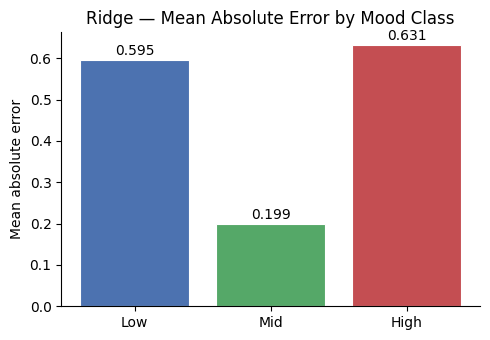

In [54]:
# Ridge Mean Absolute Error by Mood Class Plot
abs_err = np.abs(residuals_ridge_orig) # Using original ridge residuals
mood_class = pd.cut(y_test_reg, bins=[0, q33, q66, 10],
                    labels=['Low', 'Mid', 'High'])
err_by_class = pd.DataFrame({'abs_error': abs_err, 'class': mood_class})

fig, ax = plt.subplots(figsize=(5, 3.5))
means = err_by_class.groupby('class')['abs_error'].mean()
bars = ax.bar(means.index, means.values,
              color=['#4C72B0', '#55A868', '#C44E52'],
              edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Mean absolute error')
ax.set_title('Ridge — Mean Absolute Error by Mood Class')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Random Forest Regressor

In [55]:
# Initialize and train RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train_reg)
rf_reg_pred = rf_reg.predict(X_test)

# Calculate metrics
rf_reg_mse = mean_squared_error(y_test_reg, rf_reg_pred)
rf_reg_mae = mean_absolute_error(y_test_reg, rf_reg_pred)
rf_reg_rmse = np.sqrt(rf_reg_mse)

print("\n=== RANDOM FOREST REGRESSOR ===")
print(f"MSE: {rf_reg_mse:.3f}")
print(f"MAE: {rf_reg_mae:.3f}")
print(f"RMSE: {rf_reg_rmse:.3f}")


=== RANDOM FOREST REGRESSOR ===
MSE: 0.456
MAE: 0.510
RMSE: 0.675


# 4. Association Rule Mining

In [56]:
# Helper function to discretize continuous features into 'Low', 'Mid', 'High'
def get_quantile_bins(series):
    q_low = series.quantile(0.33)
    q_high = series.quantile(0.66)

    bins = [series.min() - 1e-6, q_low, q_high, series.max() + 1e-6]
    labels = ['Low', 'Mid', 'High']

    if q_low == q_high:
        if series.nunique() == 1:
            return pd.Series(labels[1], index=series.index)
        elif series.nunique() == 2:
            bins = [series.min() - 1e-6, q_low, series.max() + 1e-6]
            labels = ['Low', 'High']
            return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# Features to discretize for association rule mining
features_to_discretize = [
    'mood_target',
    'activity_rmean3',
    'screen_z_rmean3',
    'circumplex.valence_rmean3',
    'appCat.social_rmean3',
    'appCat.communication_rmean3',
    'appCat.entertainment_rmean3'
]

# Create a copy of the original dataframe for association rule mining
df_ar = df.copy()

# Apply discretization to the selected features
for feature in features_to_discretize:
    if feature in df_ar.columns:
        df_ar[f'{feature}_binned'] = get_quantile_bins(df_ar[feature])
    else:
        print(f"Warning: Feature '{feature}' not found in DataFrame. Skipping.")

# Select only the newly binned categorical columns
binned_cols = [col for col in df_ar.columns if col.endswith('_binned')]

# Perform one-hot encoding on the binned columns
df_encoded = pd.get_dummies(df_ar[binned_cols], prefix_sep='_')

# Ensure the DataFrame contains only 0s and 1s
df_encoded = df_encoded.astype(bool)

print("\nRunning Apriori algorithm...")
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

print("Generating association rules...")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

rules = rules[rules["lift"] > 1]

# Sort by lift
rules = rules.sort_values(by="lift", ascending=False)

print("\n=== TOP ASSOCIATION RULES ===")
display(rules[['antecedents','consequents','support','confidence','lift']].head(5))


Running Apriori algorithm...
Generating association rules...

=== TOP ASSOCIATION RULES ===


,antecedents,consequents,support,confidence,lift
18,"(appCat.entertainment_rmean3_binned_Low, appCa...",(appCat.social_rmean3_binned_Low),0.090026,0.723404,2.191489
19,"(appCat.entertainment_rmean3_binned_High, appC...",(appCat.social_rmean3_binned_High),0.095322,0.724832,2.133078
10,"(appCat.social_rmean3_binned_Low, screen_z_rme...",(appCat.communication_rmean3_binned_Low),0.089144,0.701389,2.124796
22,"(circumplex.valence_rmean3_binned_Low, appCat....",(appCat.social_rmean3_binned_High),0.052074,0.702381,2.067007
23,"(circumplex.valence_rmean3_binned_Low, appCat....",(appCat.entertainment_rmean3_binned_High),0.052074,0.702381,2.067007
